ANALISIS CENTROAMERICA
ANálisis de calidad
Ing Pedro Abarca Rios

In [1]:
import pandas as pd
import numpy as np
import io
import ipywidgets as widgets
from IPython.display import display

print("Paso 1: seleccione y suba el archivo Excel")

uploader = widgets.FileUpload(
    accept=".xlsx,.xls",
    multiple=False
)

display(uploader)

Paso 1: seleccione y suba el archivo Excel


FileUpload(value=(), accept='.xlsx,.xls', description='Upload')

In [ ]:
if not uploader.value:
    print("Primero debe subir el archivo Excel en la celda anterior.")
else:
    archivo = list(uploader.value)[0] 
    contenido = archivo['content']

    df = pd.read_excel(io.BytesIO(contenido))

    print("Archivo cargado correctamente")
    print("Dimensiones del dataset:", df.shape)
    display(df.head())

In [4]:
print("Columnas del dataset:")
for col in df.columns:
    print("-", col)

print("\nTipos de datos:")
display(df.dtypes.to_frame("tipo_dato"))

print("\nResumen general:")
display(df.describe(include="all").T)

Columnas del dataset:
- Area
- Country
- Make
- Brand
- Model
- Version
- Passenger/Commercial
- LocalSegment
- BodyType
- BodySize
- TMC Segment
- TSSD Segment
- Report
- Jan-25
- Feb-25
- Mar-25
- Apr-25
- May-25
- Jun-25
- Jul-25
- Aug-25
- Sep-25
- Oct-25
- Nov-25
- Dec-25
- YTD2025
- Q1.25
- Q2.25
- Q3.25
- Q4.25
- CH/KR/IN
- SOURCE
- Engine
- Fuel
- T/M
- B/T
- Grade
- Door
- WD
- CKD/CBU

Tipos de datos:


,tipo_dato
Area,object
Country,object
Make,object
Brand,object
Model,object
Version,object
Passenger/Commercial,object
LocalSegment,object
BodyType,object
BodySize,object



Resumen general:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Area,3528,1,Central America,3528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,3528,6,Costa Rica,1251,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Make,3528,89,TOYOTA,295,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Brand,3528,153,TOYOTA,260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,3462,1076,LAND CRUISER,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Version,325,213,PANEL,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Passenger/Commercial,3528,2,Commercial,3068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LocalSegment,3524,71,RURAL,611,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BodyType,3528,7,SUV,1685,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BodySize,3528,17,Small SUV,919,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Copia de seguridad
df_original = df.copy()

# Limpiar nombres de columnas
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.replace("/", "_", regex=False)
    .str.replace("-", "_", regex=False)
    .str.replace(".", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

print("Columnas estandarizadas:")
display(df.columns.tolist())

Columnas estandarizadas:


['Area',
 'Country',
 'Make',
 'Brand',
 'Model',
 'Version',
 'Passenger_Commercial',
 'LocalSegment',
 'BodyType',
 'BodySize',
 'TMC_Segment',
 'TSSD_Segment',
 'Report',
 'Jan_25',
 'Feb_25',
 'Mar_25',
 'Apr_25',
 'May_25',
 'Jun_25',
 'Jul_25',
 'Aug_25',
 'Sep_25',
 'Oct_25',
 'Nov_25',
 'Dec_25',
 'YTD2025',
 'Q1_25',
 'Q2_25',
 'Q3_25',
 'Q4_25',
 'CH_KR_IN',
 'SOURCE',
 'Engine',
 'Fuel',
 'T_M',
 'B_T',
 'Grade',
 'Door',
 'WD',
 'CKD_CBU']

In [6]:
columnas_meses = [
    "Jan_25", "Feb_25", "Mar_25", "Apr_25", "May_25", "Jun_25",
    "Jul_25", "Aug_25", "Sep_25", "Oct_25", "Nov_25", "Dec_25"
]

columnas_trimestres = ["Q1_25", "Q2_25", "Q3_25", "Q4_25"]
columna_ytd = "YTD2025"

# Verificación de existencia
print("Meses encontrados:", [c for c in columnas_meses if c in df.columns])
print("Trimestres encontrados:", [c for c in columnas_trimestres if c in df.columns])
print("YTD encontrado:", columna_ytd in df.columns)

Meses encontrados: ['Jan_25', 'Feb_25', 'Mar_25', 'Apr_25', 'May_25', 'Jun_25', 'Jul_25', 'Aug_25', 'Sep_25', 'Oct_25', 'Nov_25', 'Dec_25']
Trimestres encontrados: ['Q1_25', 'Q2_25', 'Q3_25', 'Q4_25']
YTD encontrado: True


In [7]:
faltantes = pd.DataFrame({
    "faltantes": df.isna().sum(),
    "porcentaje_faltantes": (df.isna().sum() / len(df) * 100).round(2)
}).sort_values("porcentaje_faltantes", ascending=False)

display(faltantes)

,faltantes,porcentaje_faltantes
Grade,3528,100.00
Door,3528,100.00
CH_KR_IN,3528,100.00
Engine,3528,100.00
B_T,3528,100.00
Report,3528,100.00
Version,3203,90.79
Dec_25,2271,64.37
Nov_25,2266,64.23
Apr_25,1850,52.44


In [8]:
# Columnas con 100% de valores faltantes
columnas_100_vacias = faltantes[faltantes["porcentaje_faltantes"] == 100].index.tolist()

print("Columnas eliminadas por tener 100% valores faltantes:")
print(columnas_100_vacias)
# Crear una copia limpia del dataset
df_limpio = df.drop(columns=columnas_100_vacias)

print("Dimensión original:", df.shape)
print("Dimensión después de eliminar columnas vacías:", df_limpio.shape)
archivo_salida =r"C:\Users\PIAbarcaR\Desktop\PRESENTACIÓN CENTROAMÉRICA\2025_Centroamerica_limpio.xlsx"

df_limpio.to_excel(archivo_salida, index=False)

print("Archivo limpio generado:", archivo_salida)

Columnas eliminadas por tener 100% valores faltantes:
['Grade', 'Door', 'CH_KR_IN', 'Engine', 'B_T', 'Report']
Dimensión original: (3528, 40)
Dimensión después de eliminar columnas vacías: (3528, 34)
Archivo limpio generado: C:\Users\PIAbarcaR\Desktop\PRESENTACIÓN CENTROAMÉRICA\2025_Centroamerica_limpio.xlsx


In [9]:
# Detectar columnas numéricas automáticamente
columnas_numericas = df_limpio.select_dtypes(include=['int64','float64']).columns.tolist()

print("Columnas numéricas detectadas:")
print(columnas_numericas)

 # Contar negativos por columna
negativos_resumen = []

for col in columnas_numericas:
    
    negativos = (df_limpio[col] < 0).sum()
    
    negativos_resumen.append({
        "columna": col,
        "cantidad_negativos": negativos,
        "minimo": df_limpio[col].min(),
        "maximo": df_limpio[col].max()
    })

negativos_resumen = pd.DataFrame(negativos_resumen)\
                    .sort_values("cantidad_negativos", ascending=False)

display(negativos_resumen)

Columnas numéricas detectadas:
['Jan_25', 'Feb_25', 'Mar_25', 'Apr_25', 'May_25', 'Jun_25', 'Jul_25', 'Aug_25', 'Sep_25', 'Oct_25', 'Nov_25', 'Dec_25', 'YTD2025', 'Q1_25', 'Q2_25', 'Q3_25', 'Q4_25']


,columna,cantidad_negativos,minimo,maximo
11,Dec_25,4,-5.0,554.0
10,Nov_25,4,-1.0,703.0
16,Q4_25,2,-2.0,1860.0
15,Q3_25,1,-1.0,1782.0
1,Feb_25,1,-1.0,553.0
9,Oct_25,1,-1.0,603.0
5,Jun_25,1,-1.0,569.0
6,Jul_25,1,-1.0,578.0
12,YTD2025,1,-2.0,6683.0
0,Jan_25,0,0.0,636.0


In [12]:
# Crear una copia para no modificar el dataset original
df_sin_negativos = df_limpio.copy()

# Identificar columnas numéricas
columnas_numericas = df_sin_negativos.select_dtypes(include=['int64','float64']).columns

# Reemplazar negativos por 0
df_sin_negativos[columnas_numericas] = df_sin_negativos[columnas_numericas].clip(lower=0)

print("Valores negativos reemplazados por 0.")

archivo_final = r"C:\Users\PIAbarcaR\Desktop\PRESENTACIÓN CENTROAMÉRICA\2025_Centroamerica_sin_negativos.xlsx"

df_sin_negativos.to_excel(archivo_final, index=False)

print("Archivo exportado:", archivo_final)

Valores negativos reemplazados por 0.
Archivo exportado: C:\Users\PIAbarcaR\Desktop\PRESENTACIÓN CENTROAMÉRICA\2025_Centroamerica_sin_negativos.xlsx


In [13]:
df["YTD_calculado"] = df[columnas_meses].sum(axis=1)
df["diferencia"] = df["YTD2025"] - df["YTD_calculado"]

#print
print("Diferencias encontradas:")
print(df[["YTD2025", "YTD_calculado", "diferencia"]].head())



Diferencias encontradas:
   YTD2025  YTD_calculado  diferencia
0        3            3.0         0.0
1        1            1.0         0.0
2       16           16.0         0.0
3       53           53.0         0.0
4       12           12.0         0.0


In [14]:
# Lista de columnas mensuales
meses = [
    "Jan_25", "Feb_25", "Mar_25", "Apr_25", "May_25", "Jun_25",
    "Jul_25", "Aug_25", "Sep_25", "Oct_25", "Nov_25", "Dec_25"
]

# Verificar que todas las columnas existan
meses_existentes = [col for col in meses if col in df_sin_negativos.columns]

print("Meses encontrados en el dataset:")
print(meses_existentes)

# Crear columna con total anual calculado por suma de meses
df_sin_negativos["Total_Anual_Calculado"] = df_sin_negativos[meses_existentes].sum(axis=1)

# Agrupar por país y sumar el total anual
tabla_total_pais = (
    df_sin_negativos
    .groupby("Country", as_index=False)["Total_Anual_Calculado"]
    .sum()
    .sort_values("Total_Anual_Calculado", ascending=False)
    .reset_index(drop=True)
)

# Renombrar columna final para que quede más presentable
tabla_total_pais = tabla_total_pais.rename(columns={
    "Country": "Pais",
    "Total_Anual_Calculado": "Total_Carros_2025"
})

print("Tabla de total de carros por país en 2025:")
display(tabla_total_pais)

Meses encontrados en el dataset:
['Jan_25', 'Feb_25', 'Mar_25', 'Apr_25', 'May_25', 'Jun_25', 'Jul_25', 'Aug_25', 'Sep_25', 'Oct_25', 'Nov_25', 'Dec_25']
Tabla de total de carros por país en 2025:


,Pais,Total_Carros_2025
0,Guatemala,63626.0
1,Panama,60244.0
2,Costa Rica,59520.0
3,Nicaragua,33749.0
4,ElSalvador,27193.0
5,Honduras,22961.0


In [ ]:
# Lista de columnas de meses
meses = [
    "Jan_25", "Feb_25", "Mar_25", "Apr_25", "May_25", "Jun_25",
    "Jul_25", "Aug_25", "Sep_25", "Oct_25", "Nov_25", "Dec_25"
]

meses_existentes = [col for col in meses if col in df_sin_negativos.columns]

# Crear total anual por fila
df_sin_negativos["Total_Anual"] = df_sin_negativos[meses_existentes].sum(axis=1)

# Agrupar por país y tipo de carrocería
tabla_bodytype = (
    df_sin_negativos
    .groupby(["Country","BodyType"], as_index=False)["Total_Anual"]
    .sum()
)

# Calcular total por país
totales_pais = tabla_bodytype.groupby("Country")["Total_Anual"].transform("sum")

# Calcular porcentaje de composición
tabla_bodytype["Porcentaje"] = (
    tabla_bodytype["Total_Anual"] / totales_pais * 100
).round(2)

# Ordenar resultados
tabla_bodytype = tabla_bodytype.sort_values(["Country","Porcentaje"], ascending=[True, False])

display(tabla_bodytype)

,Country,BodyType,Total_Anual,Porcentaje
2,Costa Rica,SUV,40073.0,67.33
0,Costa Rica,Pickup,8436.0,14.17
1,Costa Rica,Regular,4171.0,7.01
4,Costa Rica,Truck/Bus,4080.0,6.85
6,Costa Rica,Van,2682.0,4.51
3,Costa Rica,Sports&Specially,74.0,0.12
5,Costa Rica,Unsegmented,4.0,0.01
11,ElSalvador,Truck/Bus,8947.0,32.90
7,ElSalvador,Pickup,8289.0,30.48
9,ElSalvador,SUV,5553.0,20.42


In [ ]:
# Lista de meses
meses = [
    "Jan_25","Feb_25","Mar_25","Apr_25","May_25","Jun_25",
    "Jul_25","Aug_25","Sep_25","Oct_25","Nov_25","Dec_25"
]

meses_existentes = [col for col in meses if col in df_sin_negativos.columns]

# Total anual por fila
df_sin_negativos["Total_Anual"] = df_sin_negativos[meses_existentes].sum(axis=1)

# Agrupar por país y marca
tabla_marcas = (
    df_sin_negativos
    .groupby(["Country","Brand"], as_index=False)["Total_Anual"]
    .sum()
)

# Total por país
tabla_marcas["Total_Pais"] = tabla_marcas.groupby("Country")["Total_Anual"].transform("sum")

# Share
tabla_marcas["Share_%"] = (
    tabla_marcas["Total_Anual"] / tabla_marcas["Total_Pais"] * 100
).round(2)

# Ordenar
tabla_marcas = tabla_marcas.sort_values(["Country","Total_Anual"], ascending=[True, False])

# Crear tabla por país
paises = tabla_marcas["Country"].unique()

for pais in paises:
    
    tabla_pais = (
        tabla_marcas[tabla_marcas["Country"] == pais]
        .head(10)
        .reset_index(drop=True)
    )
    
    print("\n")
    print("TOP 10 MARCAS -", pais.upper())
    
    display(tabla_pais[["Brand","Total_Anual","Share_%"]])



TOP 10 MARCAS - COSTA RICA


,Brand,Total_Anual,Share_%
0,TOYOTA,11127.0,18.69
1,NISSAN,5791.0,9.73
2,SUZUKI,4674.0,7.85
3,GEELY,3460.0,5.81
4,BYD,3357.0,5.64
5,MITSUBISHI,3033.0,5.10
6,HYUNDAI,3018.0,5.07
7,CHERY,2046.0,3.44
8,KIA,2042.0,3.43
9,ISUZU,1795.0,3.02




TOP 10 MARCAS - ELSALVADOR


,Brand,Total_Anual,Share_%
0,TOYOTA,5499.0,20.22
1,KIA,3549.0,13.05
2,ISUZU,2284.0,8.40
3,MITSUBISHI,1964.0,7.22
4,NISSAN,1961.0,7.21
5,HYUNDAI,1829.0,6.73
6,JMC,1229.0,4.52
7,SUZUKI,1045.0,3.84
8,CHEVROLET,1021.0,3.75
9,HINO,689.0,2.53




TOP 10 MARCAS - GUATEMALA


...

,Brand,Total_Anual,Share_%
0,TOYOTA,7135.0,31.07
1,MITSUBISHI,2556.0,11.13
2,NISSAN,2409.0,10.49
3,ISUZU,1961.0,8.54
4,KIA,1595.0,6.95
5,FORD,977.0,4.26
6,HYUNDAI,929.0,4.05
7,SUZUKI,793.0,3.45
8,MAZDA,676.0,2.94
9,CHEVROLET,611.0,2.66




TOP 10 MARCAS - NICARAGUA


,Brand,Total_Anual,Share_%
0,TOYOTA,14152.0,41.93
1,SUZUKI,3802.0,11.27
2,KIA,2785.0,8.25
3,HYUNDAI,2634.0,7.80
4,HINO,1630.0,4.83
5,ISUZU,1353.0,4.01
6,NISSAN,1181.0,3.50
7,MITSUBISHI,1146.0,3.40
8,CHEVROLET,950.0,2.81
9,CHERY,663.0,1.96




TOP 10 MARCAS - PANAMA


,Brand,Total_Anual,Share_%
0,TOYOTA,11511.0,19.11
1,KIA,7626.0,12.66
2,HYUNDAI,6985.0,11.59
3,GEELY,3171.0,5.26
4,SUZUKI,3094.0,5.14
5,NISSAN,2166.0,3.60
6,MITSUBISHI,2033.0,3.37
7,JETOUR,1999.0,3.32
8,CHANGAN,1848.0,3.07
9,ISUZU,1747.0,2.90


In [ ]:
# Lista de meses
meses = [
    "Jan_25","Feb_25","Mar_25","Apr_25","May_25","Jun_25",
    "Jul_25","Aug_25","Sep_25","Oct_25","Nov_25","Dec_25"
]

meses_existentes = [col for col in meses if col in df_sin_negativos.columns]

# Total anual por fila
df_sin_negativos["Total_Anual"] = df_sin_negativos[meses_existentes].sum(axis=1)

# Unidades por país y marca
tabla_marcas = (
    df_sin_negativos
    .groupby(["Country","Brand"], as_index=False)["Total_Anual"]
    .sum()
)

# Total mercado por país
tabla_marcas["Total_Pais"] = tabla_marcas.groupby("Country")["Total_Anual"].transform("sum")

# Calcular share
tabla_marcas["Share"] = tabla_marcas["Total_Anual"] / tabla_marcas["Total_Pais"]

# Filtrar marcas con share mayor a 1%
marcas_relevantes = tabla_marcas[tabla_marcas["Share"] > 0.01]

# Contar marcas relevantes por país
conteo_marcas = (
    marcas_relevantes
    .groupby("Country")["Brand"]
    .nunique()
    .reset_index()
)

# Renombrar columnas
conteo_marcas = conteo_marcas.rename(columns={
    "Country":"Pais",
    "Brand":"Marcas_con_mas_de_1%_share"
})

display(conteo_marcas)

,Pais,Marcas_con_mas_de_1%_share
0,Costa Rica,18
1,ElSalvador,22
2,Guatemala,19
3,Honduras,16
4,Nicaragua,13
5,Panama,20


In [ ]:
# Lista de meses
meses = [
    "Jan_25","Feb_25","Mar_25","Apr_25","May_25","Jun_25",
    "Jul_25","Aug_25","Sep_25","Oct_25","Nov_25","Dec_25"
]

meses_existentes = [col for col in meses if col in df_sin_negativos.columns]

# Total anual por fila
df_sin_negativos["Total_Anual"] = df_sin_negativos[meses_existentes].sum(axis=1)

# Total mercado por país
total_pais = (
    df_sin_negativos
    .groupby("Country")["Total_Anual"]
    .sum()
    .reset_index()
    .rename(columns={"Total_Anual":"Total_Mercado"})
)

# Total Toyota por país
toyota_pais = (
    df_sin_negativos[df_sin_negativos["Brand"] == "TOYOTA"]
    .groupby("Country")["Total_Anual"]
    .sum()
    .reset_index()
    .rename(columns={"Total_Anual":"Unidades_Toyota"})
)

# Unir tablas
share_toyota = total_pais.merge(toyota_pais, on="Country", how="left")

# Calcular share
share_toyota["Share_Toyota_%"] = (
    share_toyota["Unidades_Toyota"] / share_toyota["Total_Mercado"] * 100
).round(2)

# Renombrar columnas
share_toyota = share_toyota.rename(columns={"Country":"Pais"})

display(share_toyota)

,Pais,Total_Mercado,Unidades_Toyota,Share_Toyota_%
0,Costa Rica,59520.0,11127.0,18.69
1,ElSalvador,27193.0,5499.0,20.22
2,Guatemala,63626.0,17252.0,27.11
3,Honduras,22961.0,7135.0,31.07
4,Nicaragua,33749.0,14152.0,41.93
5,Panama,60244.0,11511.0,19.11


In [ ]:
# Lista de meses
meses = [
    "Jan_25","Feb_25","Mar_25","Apr_25","May_25","Jun_25",
    "Jul_25","Aug_25","Sep_25","Oct_25","Nov_25","Dec_25"
]

meses_existentes = [col for col in meses if col in df_sin_negativos.columns]

# Total anual por fila
df_sin_negativos["Total_Anual"] = df_sin_negativos[meses_existentes].sum(axis=1)

# Total mercado por país
total_pais = (
    df_sin_negativos
    .groupby("Country")["Total_Anual"]
    .sum()
    .reset_index()
    .rename(columns={"Total_Anual":"Total_Mercado"})
)

# Total Lexus por país
lexus_pais = (
    df_sin_negativos[df_sin_negativos["Brand"] == "LEXUS"]
    .groupby("Country")["Total_Anual"]
    .sum()
    .reset_index()
    .rename(columns={"Total_Anual":"Unidades_Lexus"})
)

# Unir tablas
share_lexus = total_pais.merge(lexus_pais, on="Country", how="left")

# Reemplazar NaN por 0 (países donde Lexus no tiene ventas)
share_lexus["Unidades_Lexus"] = share_lexus["Unidades_Lexus"].fillna(0)

# Calcular share
share_lexus["Share_Lexus_%"] = (
    share_lexus["Unidades_Lexus"] / share_lexus["Total_Mercado"] * 100
).round(2)

# Renombrar columnas
share_lexus = share_lexus.rename(columns={"Country":"Pais"})

display(share_lexus)

,Pais,Total_Mercado,Unidades_Lexus,Share_Lexus_%
0,Costa Rica,59520.0,306.0,0.51
1,ElSalvador,27193.0,1.0,0.00
2,Guatemala,63626.0,803.0,1.26
3,Honduras,22961.0,3.0,0.01
4,Nicaragua,33749.0,0.0,0.00
5,Panama,60244.0,79.0,0.13


In [ ]:
# Lista de meses
meses = [
    "Jan_25","Feb_25","Mar_25","Apr_25","May_25","Jun_25",
    "Jul_25","Aug_25","Sep_25","Oct_25","Nov_25","Dec_25"
]

meses_existentes = [col for col in meses if col in df_sin_negativos.columns]

# Total anual por fila
df_sin_negativos["Total_Anual"] = df_sin_negativos[meses_existentes].sum(axis=1)

# Filtrar solo segmento Luxury
df_luxury = df_sin_negativos[
    df_sin_negativos["TMC_Segment"].str.startswith("Luxury", na=False)
]

# Total Luxury por país
total_luxury_pais = (
    df_luxury
    .groupby("Country")["Total_Anual"]
    .sum()
    .reset_index()
    .rename(columns={"Total_Anual":"Total_Luxury_Mercado"})
)

# Lexus dentro del segmento Luxury
lexus_luxury = (
    df_luxury[df_luxury["Brand"] == "LEXUS"]
    .groupby("Country")["Total_Anual"]
    .sum()
    .reset_index()
    .rename(columns={"Total_Anual":"Unidades_Lexus_Luxury"})
)

# Unir tablas
share_lexus_luxury = total_luxury_pais.merge(lexus_luxury, on="Country", how="left")

# Reemplazar NaN por 0
share_lexus_luxury["Unidades_Lexus_Luxury"] = share_lexus_luxury["Unidades_Lexus_Luxury"].fillna(0)

# Calcular share
share_lexus_luxury["Share_Lexus_Luxury_%"] = (
    share_lexus_luxury["Unidades_Lexus_Luxury"] /
    share_lexus_luxury["Total_Luxury_Mercado"] * 100
).round(2)

# Renombrar
share_lexus_luxury = share_lexus_luxury.rename(columns={"Country":"Pais"})

display(share_lexus_luxury)

,Pais,Total_Luxury_Mercado,Unidades_Lexus_Luxury,Share_Lexus_Luxury_%
0,Costa Rica,2513.0,306.0,12.18
1,ElSalvador,349.0,1.0,0.29
2,Guatemala,2278.0,803.0,35.25
3,Honduras,169.0,3.0,1.78
4,Nicaragua,30.0,0.0,0.00
5,Panama,2307.0,79.0,3.42


In [ ]:
# Lista de meses
meses = [
    "Jan_25","Feb_25","Mar_25","Apr_25","May_25","Jun_25",
    "Jul_25","Aug_25","Sep_25","Oct_25","Nov_25","Dec_25"
]

meses_existentes = [col for col in meses if col in df_sin_negativos.columns]

# Total anual por fila
df_sin_negativos["Total_Anual"] = df_sin_negativos[meses_existentes].sum(axis=1)

# Filtrar solo Lexus
df_lexus = df_sin_negativos[df_sin_negativos["Brand"] == "LEXUS"]

# Unidades por país y modelo
tabla_modelos_lexus = (
    df_lexus
    .groupby(["Country","Model"], as_index=False)["Total_Anual"]
    .sum()
)

# Total Lexus por país
tabla_modelos_lexus["Total_Lexus_Pais"] = (
    tabla_modelos_lexus
    .groupby("Country")["Total_Anual"]
    .transform("sum")
)

# Share dentro de Lexus
tabla_modelos_lexus["Share_dentro_Lexus_%"] = (
    tabla_modelos_lexus["Total_Anual"] /
    tabla_modelos_lexus["Total_Lexus_Pais"] * 100
).round(2)

# Ordenar
tabla_modelos_lexus = tabla_modelos_lexus.sort_values(
    ["Country","Total_Anual"],
    ascending=[True, False]
)

# Crear tabla por país
paises = tabla_modelos_lexus["Country"].unique()

for pais in paises:
    
    tabla_pais = (
        tabla_modelos_lexus[tabla_modelos_lexus["Country"] == pais]
        .reset_index(drop=True)
    )
    
    print("\n")
    print("MODELOS LEXUS -", pais.upper())
    
    display(
        tabla_pais[["Model","Total_Anual","Share_dentro_Lexus_%"]]
    )



MODELOS LEXUS - COSTA RICA


,Model,Total_Anual,Share_dentro_Lexus_%
0,LBX,93.0,30.39
1,NX,85.0,27.78
2,RX,40.0,13.07
3,GX,22.0,7.19
4,RZ,22.0,7.19
5,UX 350,17.0,5.56
6,GX 550,14.0,4.58
7,LX 500,8.0,2.61
8,LX 700,5.0,1.63




MODELOS LEXUS - ELSALVADOR


,Model,Total_Anual,Share_dentro_Lexus_%
0,LS 500,1.0,100.0




MODELOS LEXUS - GUATEMALA


,Model,Total_Anual,Share_dentro_Lexus_%
0,GX 550,225.0,28.02
1,NX 350,188.0,23.41
2,LBX,128.0,15.94
3,LX 700,96.0,11.96
4,UX 300,80.0,9.96
5,RX 350,31.0,3.86
6,LX 500,17.0,2.12
7,RX 500,16.0,1.99
8,LX 600,12.0,1.49
9,IS 300,6.0,0.75




MODELOS LEXUS - HONDURAS


,Model,Total_Anual,Share_dentro_Lexus_%
0,LX 600,3.0,100.0




MODELOS LEXUS - PANAMA


,Model,Total_Anual,Share_dentro_Lexus_%
0,GX,15.0,18.99
1,LX,13.0,16.46
2,NX,13.0,16.46
3,RZ,13.0,16.46
4,TX,10.0,12.66
5,UX,9.0,11.39
6,RX,3.0,3.80
7,IS,2.0,2.53
8,LBX,1.0,1.27


In [ ]:
# Lista de meses
meses = [
    "Jan_25","Feb_25","Mar_25","Apr_25","May_25","Jun_25",
    "Jul_25","Aug_25","Sep_25","Oct_25","Nov_25","Dec_25"
]

meses_existentes = [col for col in meses if col in df_sin_negativos.columns]

# Total anual por fila
df_sin_negativos["Total_Anual"] = df_sin_negativos[meses_existentes].sum(axis=1)

# Total mercado por país
total_mercado = (
    df_sin_negativos
    .groupby("Country")["Total_Anual"]
    .sum()
    .reset_index()
    .rename(columns={"Total_Anual":"Total_Mercado"})
)

# Unidades Subaru por país
subaru_pais = (
    df_sin_negativos[df_sin_negativos["Brand"] == "SUBARU"]
    .groupby("Country")["Total_Anual"]
    .sum()
    .reset_index()
    .rename(columns={"Total_Anual":"Unidades_Subaru"})
)

# Unir tablas
share_subaru = total_mercado.merge(subaru_pais, on="Country", how="left")

# Si Subaru no existe en algún país
share_subaru["Unidades_Subaru"] = share_subaru["Unidades_Subaru"].fillna(0)

# Calcular share
share_subaru["Share_Subaru_%"] = (
    share_subaru["Unidades_Subaru"] /
    share_subaru["Total_Mercado"] * 100
).round(2)

# Renombrar columna país
share_subaru = share_subaru.rename(columns={"Country":"Pais"})

display(share_subaru)

,Pais,Total_Mercado,Unidades_Subaru,Share_Subaru_%
0,Costa Rica,59520.0,61.0,0.10
1,ElSalvador,27193.0,0.0,0.00
2,Guatemala,63626.0,392.0,0.62
3,Honduras,22961.0,0.0,0.00
4,Nicaragua,33749.0,0.0,0.00
5,Panama,60244.0,327.0,0.54


In [ ]:
import pandas as pd

# Lista de meses
meses = [
    "Jan_25","Feb_25","Mar_25","Apr_25","May_25","Jun_25",
    "Jul_25","Aug_25","Sep_25","Oct_25","Nov_25","Dec_25"
]

meses_existentes = [col for col in meses if col in df_sin_negativos.columns]

# Crear Total_Anual solo si no existe
if "Total_Anual" not in df_sin_negativos.columns:
    df_sin_negativos["Total_Anual"] = df_sin_negativos[meses_existentes].sum(axis=1)

In [ ]:
def calcular_share_marca_por_pais(df, marca, col_pais="Country", col_marca="Brand", col_total="Total_Anual"):
    """
    Calcula el share de una marca por país dentro del mercado total.

    Parámetros:
    - df: DataFrame base
    - marca: marca a analizar, por ejemplo 'TOYOTA'
    - col_pais: nombre de la columna de país
    - col_marca: nombre de la columna de marca
    - col_total: nombre de la columna de total anual

    Retorna:
    - DataFrame con total mercado, unidades de la marca y share %
    """
    
    marca = str(marca).strip().upper()
    
    df_temp = df.copy()
    df_temp[col_marca] = df_temp[col_marca].astype(str).str.strip().str.upper()
    
    # Total mercado por país
    total_mercado = (
        df_temp
        .groupby(col_pais, as_index=False)[col_total]
        .sum()
        .rename(columns={col_total: "Total_Mercado"})
    )
    
    # Total marca por país
    marca_pais = (
        df_temp[df_temp[col_marca] == marca]
        .groupby(col_pais, as_index=False)[col_total]
        .sum()
        .rename(columns={col_total: f"Unidades_{marca}"})
    )
    
    # Unir
    resultado = total_mercado.merge(marca_pais, on=col_pais, how="left")
    resultado[f"Unidades_{marca}"] = resultado[f"Unidades_{marca}"].fillna(0)
    
    # Share
    resultado[f"Share_{marca}_%"] = (
        resultado[f"Unidades_{marca}"] / resultado["Total_Mercado"] * 100
    ).round(2)
    
    resultado = resultado.rename(columns={col_pais: "Pais"})
    resultado = resultado.sort_values(f"Share_{marca}_%", ascending=False).reset_index(drop=True)
    
    return resultado

In [ ]:
def analizar_modelos_marca_por_pais(df, marca, col_pais="Country", col_marca="Brand", col_modelo="Model", col_total="Total_Anual"):
    """
    Genera tablas por país con los modelos de una marca, sus unidades
    y el share dentro de la misma marca.

    Parámetros:
    - df: DataFrame base
    - marca: marca a analizar, por ejemplo 'LEXUS'
    - col_pais: nombre de la columna país
    - col_marca: nombre de la columna marca
    - col_modelo: nombre de la columna modelo
    - col_total: nombre de la columna total anual

    Retorna:
    - diccionario con una tabla por país
    - tabla consolidada completa
    """
    
    marca = str(marca).strip().upper()
    
    df_temp = df.copy()
    df_temp[col_marca] = df_temp[col_marca].astype(str).str.strip().str.upper()
    df_temp[col_modelo] = df_temp[col_modelo].astype(str).str.strip()
    
    # Filtrar marca
    df_marca = df_temp[df_temp[col_marca] == marca].copy()
    
    # Agrupar por país y modelo
    tabla = (
        df_marca
        .groupby([col_pais, col_modelo], as_index=False)[col_total]
        .sum()
    )
    
    # Total de la marca por país
    tabla[f"Total_{marca}_Pais"] = tabla.groupby(col_pais)[col_total].transform("sum")
    
    # Share dentro de la marca
    tabla[f"Share_dentro_{marca}_%"] = (
        tabla[col_total] / tabla[f"Total_{marca}_Pais"] * 100
    ).round(2)
    
    # Ordenar
    tabla = tabla.sort_values([col_pais, col_total], ascending=[True, False]).reset_index(drop=True)
    
    # Separar por país en diccionario
    tablas_por_pais = {}
    for pais in tabla[col_pais].dropna().unique():
        tablas_por_pais[pais] = (
            tabla[tabla[col_pais] == pais]
            [[col_modelo, col_total, f"Share_dentro_{marca}_%"]]
            .rename(columns={
                col_modelo: "Model",
                col_total: "Total_Anual"
            })
            .reset_index(drop=True)
        )
    
    return tablas_por_pais, tabla

In [ ]:
analizar_modelos_marca_por_pais(df_sin_negativos, marca="SUBARU")

({'Costa Rica':        Model  Total_Anual  Share_dentro_SUBARU_%
  0   FORESTER         38.0                  62.30
  1  CROSSTREK         20.0                  32.79
  2    OUTBACK          3.0                   4.92,
  'Guatemala':       Model  Total_Anual  Share_dentro_SUBARU_%
  0  FORESTER        186.0                  47.45
  1        XV        172.0                  43.88
  2   EVOLTIS         24.0                   6.12
  3   OUTBACK          5.0                   1.28
  4       WRX          5.0                   1.28,
  'Panama':        Model  Total_Anual  Share_dentro_SUBARU_%
  0   FORESTER        138.0                  42.20
  1  CROSSTREK        135.0                  41.28
  2    EVOLTIS         41.0                  12.54
  3        WRX          8.0                   2.45
  4    OUTBACK          4.0                   1.22
  5         XV          1.0                   0.31},
        Country      Model  Total_Anual  Total_SUBARU_Pais  \
 0   Costa Rica   FORESTER         3

In [ ]:
calcular_share_marca_por_pais(df_sin_negativos, marca="HINO")

,Pais,Total_Mercado,Unidades_HINO,Share_HINO_%
0,Nicaragua,33749.0,1630.0,4.83
1,Guatemala,63626.0,3006.0,4.72
2,ElSalvador,27193.0,689.0,2.53
3,Honduras,22961.0,557.0,2.43
4,Costa Rica,59520.0,565.0,0.95
5,Panama,60244.0,344.0,0.57


In [ ]:
analizar_modelos_marca_por_pais(df_sin_negativos, marca="HINO")

({'Costa Rica':       Model  Total_Anual  Share_dentro_HINO_%
  0    XZU600        113.0                20.00
  1    XZU710        102.0                18.05
  2     LY230         98.0                17.35
  3    XZU720         73.0                12.92
  4    XZU730         55.0                 9.73
  5       FG8         38.0                 6.73
  6    XZU650         27.0                 4.78
  7       GD8         18.0                 3.19
  8       FC9         17.0                 3.01
  9       GH8         14.0                 2.48
  10      FM8          8.0                 1.42
  11  SH1EEVA          1.0                 0.18
  12  SS1EKVA          1.0                 0.18,
  'ElSalvador':     Model  Total_Anual  Share_dentro_HINO_%
  0   LY230        299.0                43.40
  1  XZU650        171.0                24.82
  2  XZU720         54.0                 7.84
  3     FC9         51.0                 7.40
  4  XZU730         45.0                 6.53
  5  XZU600         35.

In [ ]:
calcular_share_marca_por_pais(df_sin_negativos, marca="FORD")

,Pais,Total_Mercado,Unidades_FORD,Share_FORD_%
0,Honduras,22961.0,977.0,4.26
1,Panama,60244.0,1315.0,2.18
2,ElSalvador,27193.0,292.0,1.07
3,Guatemala,63626.0,615.0,0.97
4,Costa Rica,59520.0,565.0,0.95
5,Nicaragua,33749.0,183.0,0.54


In [ ]:
analizar_modelos_marca_por_pais(df_sin_negativos, marca="FORD")

({'Costa Rica':              Model  Total_Anual  Share_dentro_FORD_%
  0           RANGER        165.0                29.20
  1          EVEREST        145.0                25.66
  2        TERRITORY         82.0                14.51
  3           BRONCO         72.0                12.74
  4            F-150         31.0                 5.49
  5         EXPLORER         27.0                 4.78
  6       EXPEDITION         23.0                 4.07
  7          TRANSIT         11.0                 1.95
  8            F-350          3.0                 0.53
  9          MUSTANG          3.0                 0.53
  10           F-250          1.0                 0.18
  11        MAVERICK          1.0                 0.18
  12  MUSTANG MACH-E          1.0                 0.18,
  'ElSalvador':         Model  Total_Anual  Share_dentro_FORD_%
  0      RANGER         88.0                30.14
  1      RAPTOR         55.0                18.84
  2      BRONCO         41.0                14.04
 

In [ ]:
calcular_share_marca_por_pais(df_sin_negativos, marca="VW")

,Pais,Total_Mercado,Unidades_VW,Share_VW_%
0,Guatemala,63626.0,2315.0,3.64
1,ElSalvador,27193.0,660.0,2.43
2,Honduras,22961.0,477.0,2.08
3,Costa Rica,59520.0,466.0,0.78
4,Panama,60244.0,305.0,0.51
5,Nicaragua,33749.0,0.0,0.00


In [ ]:
analizar_modelos_marca_por_pais(df_sin_negativos, marca="VW")


({'Costa Rica':             Model  Total_Anual  Share_dentro_VW_%
  0         T-CROSS         68.0              14.59
  1          AMAROK         63.0              13.52
  2           NIVUS         63.0              13.52
  3         SAVEIRO         50.0              10.73
  4   CONSTELLATION         44.0               9.44
  5          TIGUAN         38.0               8.15
  6            ID.4         33.0               7.08
  7            TAOS         22.0               4.72
  8         ID.UNYX         19.0               4.08
  9            ID.6         16.0               3.43
  10           TERA         13.0               2.79
  11           ID.3         11.0               2.36
  12       DELIVERY         10.0               2.15
  13          17280          4.0               0.86
  14           9160          4.0               0.86
  15         METEOR          3.0               0.64
  16          JETTA          2.0               0.43
  17            nan          2.0               0.4

In [ ]:
# Lista de meses
meses = [
    "Jan_25","Feb_25","Mar_25","Apr_25","May_25","Jun_25",
    "Jul_25","Aug_25","Sep_25","Oct_25","Nov_25","Dec_25"
]

meses_existentes = [col for col in meses if col in df_sin_negativos.columns]

# Crear Total_Anual si no existe
if "Total_Anual" not in df_sin_negativos.columns:
    df_sin_negativos["Total_Anual"] = df_sin_negativos[meses_existentes].sum(axis=1)

# Estandarizar Source por seguridad
df_temp = df_sin_negativos.copy()
df_temp["SOURCE"] = df_temp["SOURCE"].astype(str).str.strip().str.upper()

# Total mercado por país
total_mercado = (
    df_temp
    .groupby("Country", as_index=False)["Total_Anual"]
    .sum()
    .rename(columns={"Total_Anual": "Total_Mercado"})
)

# Total de marcas chinas por país
china_pais = (
    df_temp[df_temp["SOURCE"] == "CHINA"]
    .groupby("Country", as_index=False)["Total_Anual"]
    .sum()
    .rename(columns={"Total_Anual": "Unidades_China"})
)

# Unir tablas
share_china = total_mercado.merge(china_pais, on="Country", how="left")

# Rellenar nulos
share_china["Unidades_China"] = share_china["Unidades_China"].fillna(0)

# Calcular share
share_china["Share_China_%"] = (
    share_china["Unidades_China"] / share_china["Total_Mercado"] * 100
).round(2)

# Renombrar y ordenar
share_china = (
    share_china
    .rename(columns={"Country": "Pais"})
    .sort_values("Share_China_%", ascending=False)
    .reset_index(drop=True)
)

display(share_china)

,Pais,Total_Mercado,Unidades_China,Share_China_%
0,Costa Rica,59520.0,21601.0,36.29
1,Guatemala,63626.0,13292.0,20.89
2,ElSalvador,27193.0,5600.0,20.59
3,Nicaragua,33749.0,4392.0,13.01
4,Honduras,22961.0,1858.0,8.09
5,Panama,60244.0,0.0,0.00


In [ ]:
# Lista de meses
meses = [
    "Jan_25","Feb_25","Mar_25","Apr_25","May_25","Jun_25",
    "Jul_25","Aug_25","Sep_25","Oct_25","Nov_25","Dec_25"
]

meses_existentes = [col for col in meses if col in df_sin_negativos.columns]

# Crear Total_Anual si no existe
if "Total_Anual" not in df_sin_negativos.columns:
    df_sin_negativos["Total_Anual"] = df_sin_negativos[meses_existentes].sum(axis=1)

# Estandarizar Source
df_temp = df_sin_negativos.copy()
df_temp["SOURCE"] = df_temp["SOURCE"].astype(str).str.strip().str.upper()

# Total mercado por país
total_mercado = (
    df_temp
    .groupby("Country")["Total_Anual"]
    .sum()
    .reset_index()
    .rename(columns={"Total_Anual": "Total_Mercado"})
)

# Filtrar solo marcas chinas
df_china = df_temp[df_temp["SOURCE"] == "CHINA"]

# Unidades por país y marca
tabla_marcas_china = (
    df_china
    .groupby(["Country","Brand"], as_index=False)["Total_Anual"]
    .sum()
)

# Agregar total mercado
tabla_marcas_china = tabla_marcas_china.merge(total_mercado, on="Country", how="left")

# Calcular share
tabla_marcas_china["Share_%"] = (
    tabla_marcas_china["Total_Anual"] /
    tabla_marcas_china["Total_Mercado"] * 100
).round(2)

# Ordenar
tabla_marcas_china = tabla_marcas_china.sort_values(
    ["Country","Total_Anual"],
    ascending=[True, False]
)

# Crear tabla por país (Top 5)
paises = tabla_marcas_china["Country"].unique()

for pais in paises:
    
    tabla_pais = (
        tabla_marcas_china[tabla_marcas_china["Country"] == pais]
        .head(5)
        .reset_index(drop=True)
    )
    
    print("\n")
    print("TOP 5 MARCAS CHINAS -", pais.upper())
    
    display(
        tabla_pais[["Brand","Total_Anual","Share_%"]]
    )



TOP 5 MARCAS CHINAS - COSTA RICA


,Brand,Total_Anual,Share_%
0,GEELY,3460.0,5.81
1,BYD,3346.0,5.62
2,CHERY,2046.0,3.44
3,CHANGAN,1460.0,2.45
4,JAC,1056.0,1.77




TOP 5 MARCAS CHINAS - ELSALVADOR


,Brand,Total_Anual,Share_%
0,JMC,1229.0,4.52
1,CHEVROLET,872.0,3.21
2,FORLAND,677.0,2.49
3,FOTON,533.0,1.96
4,CHERY,471.0,1.73




TOP 5 MARCAS CHINAS - GUATEMALA


,Brand,Total_Anual,Share_%
0,JAC,3672.0,5.77
1,CHANGAN,2954.0,4.64
2,FOTON,2339.0,3.68
3,JIM,734.0,1.15
4,BYD,727.0,1.14




TOP 5 MARCAS CHINAS - HONDURAS


,Brand,Total_Anual,Share_%
0,JAC,375.0,1.63
1,FOTON,325.0,1.42
2,FORLAND,295.0,1.28
3,CHEVROLET,239.0,1.04
4,CHERY,149.0,0.65




TOP 5 MARCAS CHINAS - NICARAGUA


,Brand,Total_Anual,Share_%
0,CHERY,663.0,1.96
1,FORLAND,662.0,1.96
2,CHEVROLET,554.0,1.64
3,FOTON,528.0,1.56
4,GEELY,483.0,1.43


In [ ]:
# =====================================
# 1. Preparar dataset
# =====================================

meses = [
    "Jan_25","Feb_25","Mar_25","Apr_25","May_25","Jun_25",
    "Jul_25","Aug_25","Sep_25","Oct_25","Nov_25","Dec_25"
]

meses_existentes = [c for c in meses if c in df_sin_negativos.columns]

df_temp = df_sin_negativos.copy()

# Crear total anual
if "Total_Anual" not in df_temp.columns:
    df_temp["Total_Anual"] = df_temp[meses_existentes].sum(axis=1)

# Normalizar marca y país
df_temp["Brand"] = df_temp["Brand"].astype(str).str.strip().str.upper()
df_temp["Country"] = df_temp["Country"].astype(str).str.strip().str.upper()

# =====================================
# 2. Definir marcas chinas
# =====================================

marcas_chinas = [
    "GEELY",
    "CHANGAN",
    "DONGFENG",
    "JETOUR",
    "GAC"
]

# =====================================
# 3. Total mercado por país
# =====================================

total_mercado = (
    df_temp
    .groupby("Country", as_index=False)["Total_Anual"]
    .sum()
    .rename(columns={"Total_Anual":"Total_Mercado"})
)

# =====================================
# 4. Unidades por marca china
# =====================================

df_china = df_temp[df_temp["Brand"].isin(marcas_chinas)]

tabla_marcas = (
    df_china
    .groupby(["Country","Brand"], as_index=False)["Total_Anual"]
    .sum()
)

# =====================================
# 5. Calcular share individual
# =====================================

tabla_marcas = tabla_marcas.merge(total_mercado, on="Country", how="left")

tabla_marcas["Share_%"] = (
    tabla_marcas["Total_Anual"] /
    tabla_marcas["Total_Mercado"] * 100
).round(2)

# =====================================
# 6. Share conjunto de esas marcas
# =====================================

share_conjunto = (
    tabla_marcas
    .groupby("Country", as_index=False)["Total_Anual"]
    .sum()
    .rename(columns={"Total_Anual":"Unidades_Chinas_Seleccionadas"})
)

share_conjunto = share_conjunto.merge(total_mercado, on="Country")

share_conjunto["Share_Total_%"] = (
    share_conjunto["Unidades_Chinas_Seleccionadas"] /
    share_conjunto["Total_Mercado"] * 100
).round(2)

# =====================================
# 7. Mostrar resultados
# =====================================

paises = tabla_marcas["Country"].unique()

for pais in paises:

    print("\n")
    print("MARCAS CHINAS SELECCIONADAS -", pais)

    tabla_pais = tabla_marcas[
        tabla_marcas["Country"] == pais
    ].sort_values("Total_Anual", ascending=False)

    display(
        tabla_pais[["Brand","Total_Anual","Share_%"]]
    )

    share_total = share_conjunto[
        share_conjunto["Country"] == pais
    ]

    print("Share conjunto de estas marcas:")
    display(share_total[["Unidades_Chinas_Seleccionadas","Share_Total_%"]])



MARCAS CHINAS SELECCIONADAS - COSTA RICA


,Brand,Total_Anual,Share_%
3,GEELY,3460.0,5.81
0,CHANGAN,1460.0,2.45
1,DONGFENG,742.0,1.25
4,JETOUR,113.0,0.19
2,GAC,85.0,0.14


Share conjunto de estas marcas:


,Unidades_Chinas_Seleccionadas,Share_Total_%
0,5860.0,9.85




MARCAS CHINAS SELECCIONADAS - ELSALVADOR


...

,Unidades_Chinas_Seleccionadas,Share_Total_%
4,999.0,2.96




MARCAS CHINAS SELECCIONADAS - PANAMA


,Brand,Total_Anual,Share_%
21,GEELY,3171.0,5.26
22,JETOUR,1999.0,3.32
18,CHANGAN,1848.0,3.07
20,GAC,1124.0,1.87
19,DONGFENG,891.0,1.48


Share conjunto de estas marcas:


,Unidades_Chinas_Seleccionadas,Share_Total_%
5,9033.0,14.99


In [ ]:
# =====================================
# 1. Preparar dataset
# =====================================

meses = [
    "Jan_25","Feb_25","Mar_25","Apr_25","May_25","Jun_25",
    "Jul_25","Aug_25","Sep_25","Oct_25","Nov_25","Dec_25"
]

meses_existentes = [c for c in meses if c in df_sin_negativos.columns]

df_temp = df_sin_negativos.copy()

# Crear Total_Anual si no existe
if "Total_Anual" not in df_temp.columns:
    df_temp["Total_Anual"] = df_temp[meses_existentes].sum(axis=1)

# Normalizar texto
df_temp["Fuel"] = df_temp["Fuel"].astype(str).str.strip().str.upper()
df_temp["Country"] = df_temp["Country"].astype(str).str.strip().str.upper()

# =====================================
# 2. Total mercado por país
# =====================================

total_mercado = (
    df_temp
    .groupby("Country", as_index=False)["Total_Anual"]
    .sum()
    .rename(columns={"Total_Anual":"Total_Mercado"})
)

# =====================================
# 3. Unidades BEV por país
# =====================================

bev_pais = (
    df_temp[df_temp["Fuel"] == "BEV"]
    .groupby("Country", as_index=False)["Total_Anual"]
    .sum()
    .rename(columns={"Total_Anual":"Unidades_BEV"})
)

# =====================================
# 4. Calcular share
# =====================================

share_bev = total_mercado.merge(bev_pais, on="Country", how="left")

share_bev["Unidades_BEV"] = share_bev["Unidades_BEV"].fillna(0)

share_bev["Share_BEV_%"] = (
    share_bev["Unidades_BEV"] /
    share_bev["Total_Mercado"] * 100
).round(2)

share_bev = (
    share_bev
    .rename(columns={"Country":"Pais"})
    .sort_values("Share_BEV_%", ascending=False)
    .reset_index(drop=True)
)

display(share_bev)

,Pais,Total_Mercado,Unidades_BEV,Share_BEV_%
0,COSTA RICA,59520.0,10803.0,18.15
1,PANAMA,60244.0,613.0,1.02
2,GUATEMALA,63626.0,631.0,0.99
3,ELSALVADOR,27193.0,105.0,0.39
4,HONDURAS,22961.0,3.0,0.01
5,NICARAGUA,33749.0,1.0,0.00


In [ ]:
# =====================================
# 1. Preparar dataset
# =====================================

meses = [
    "Jan_25","Feb_25","Mar_25","Apr_25","May_25","Jun_25",
    "Jul_25","Aug_25","Sep_25","Oct_25","Nov_25","Dec_25"
]

meses_existentes = [c for c in meses if c in df_sin_negativos.columns]

df_temp = df_sin_negativos.copy()

# Crear Total_Anual si no existe
if "Total_Anual" not in df_temp.columns:
    df_temp["Total_Anual"] = df_temp[meses_existentes].sum(axis=1)

# Normalizar texto
df_temp["Fuel"] = df_temp["Fuel"].astype(str).str.strip().str.upper()
df_temp["Country"] = df_temp["Country"].astype(str).str.strip().str.upper()

# =====================================
# 2. Unidades por país y fuel
# =====================================

tabla_fuel = (
    df_temp
    .groupby(["Country","Fuel"], as_index=False)["Total_Anual"]
    .sum()
)

# =====================================
# 3. Total mercado por país
# =====================================

tabla_fuel["Total_Pais"] = (
    tabla_fuel
    .groupby("Country")["Total_Anual"]
    .transform("sum")
)

# =====================================
# 4. Calcular share
# =====================================

tabla_fuel["Share_%"] = (
    tabla_fuel["Total_Anual"] /
    tabla_fuel["Total_Pais"] * 100
).round(2)

# Ordenar
tabla_fuel = tabla_fuel.sort_values(["Country","Share_%"], ascending=[True, False])

# =====================================
# 5. Mostrar tabla por país
# =====================================

paises = tabla_fuel["Country"].unique()

for pais in paises:

    print("\n")
    print("COMPOSICIÓN DEL MERCADO POR FUEL -", pais)

    tabla_pais = (
        tabla_fuel[tabla_fuel["Country"] == pais]
        [["Fuel","Total_Anual","Share_%"]]
        .reset_index(drop=True)
    )

    display(tabla_pais)



COMPOSICIÓN DEL MERCADO POR FUEL - COSTA RICA


,Fuel,Total_Anual,Share_%
0,GASOLINE,29970.0,50.35
1,DIESEL,16505.0,27.73
2,BEV,10803.0,18.15
3,HEV,2236.0,3.76
4,MHEV,6.0,0.01




COMPOSICIÓN DEL MERCADO POR FUEL - ELSALVADOR


,Fuel,Total_Anual,Share_%
0,DIESEL,17914.0,65.88
1,GASOLINE,8063.0,29.65
2,HEV,1093.0,4.02
3,BEV,105.0,0.39
4,NAN,18.0,0.07




COMPOSICIÓN DEL MERCADO POR FUEL - GUATEMALA


...

,Fuel,Total_Anual,Share_%
0,DIESEL,18314.0,79.76
1,GASOLINE,4077.0,17.76
2,HEV,563.0,2.45
3,NAN,4.0,0.02
4,BEV,3.0,0.01




COMPOSICIÓN DEL MERCADO POR FUEL - NICARAGUA


,Fuel,Total_Anual,Share_%
0,NAN,33748.0,100.0
1,BEV,1.0,0.0




COMPOSICIÓN DEL MERCADO POR FUEL - PANAMA


,Fuel,Total_Anual,Share_%
0,NAN,59507.0,98.78
1,BEV,613.0,1.02
2,PHEV,123.0,0.20
3,XEV,1.0,0.00


In [ ]:
# =====================================
# 1. Preparar dataset
# =====================================

meses = [
    "Jan_25","Feb_25","Mar_25","Apr_25","May_25","Jun_25",
    "Jul_25","Aug_25","Sep_25","Oct_25","Nov_25","Dec_25"
]

meses_existentes = [c for c in meses if c in df_sin_negativos.columns]

df_temp = df_sin_negativos.copy()

# Crear Total_Anual si no existe
if "Total_Anual" not in df_temp.columns:
    df_temp["Total_Anual"] = df_temp[meses_existentes].sum(axis=1)

# Normalizar texto
df_temp["SOURCE"] = df_temp["SOURCE"].astype(str).str.strip().str.upper()
df_temp["Country"] = df_temp["Country"].astype(str).str.strip().str.upper()

# =====================================
# 2. Unidades por país y source
# =====================================

tabla_source = (
    df_temp
    .groupby(["Country","SOURCE"], as_index=False)["Total_Anual"]
    .sum()
)

# =====================================
# 3. Total mercado por país
# =====================================

tabla_source["Total_Pais"] = (
    tabla_source
    .groupby("Country")["Total_Anual"]
    .transform("sum")
)

# =====================================
# 4. Calcular share
# =====================================

tabla_source["Share_%"] = (
    tabla_source["Total_Anual"] /
    tabla_source["Total_Pais"] * 100
).round(2)

# Ordenar
tabla_source = tabla_source.sort_values(["Country","Share_%"], ascending=[True, False])

# =====================================
# 5. Mostrar tabla por país
# =====================================

paises = tabla_source["Country"].unique()

for pais in paises:

    print("\n")
    print("COMPOSICIÓN DEL MERCADO POR SOURCE -", pais)

    tabla_pais = (
        tabla_source[tabla_source["Country"] == pais]
        [["SOURCE","Total_Anual","Share_%"]]
        .reset_index(drop=True)
    )

    display(tabla_pais)



COMPOSICIÓN DEL MERCADO POR SOURCE - COSTA RICA


,SOURCE,Total_Anual,Share_%
0,CHINA,21601.0,36.29
1,JAPAN,7904.0,13.28
2,INDIA,5793.0,9.73
3,INDONESIA,5127.0,8.61
4,MEXICO,4330.0,7.27
5,ARGENTINA,3338.0,5.61
6,THAILAND,3227.0,5.42
7,KOREA,2464.0,4.14
8,BRAZIL,1802.0,3.03
9,USA,1659.0,2.79




COMPOSICIÓN DEL MERCADO POR SOURCE - ELSALVADOR


,SOURCE,Total_Anual,Share_%
0,CHINA,5600.0,20.59
1,JAPAN,4259.0,15.66
2,KOREA,4175.0,15.35
3,THAILAND,3021.0,11.11
4,ARGENTINA,2950.0,10.85
5,MEXICO,2353.0,8.65
6,INDONESIA,1733.0,6.37
7,INDIA,1496.0,5.50
8,USA,650.0,2.39
9,BRAZIL,604.0,2.22




COMPOSICIÓN DEL MERCADO POR SOURCE - GUATEMALA


...

,SOURCE,Total_Anual,Share_%
0,THAILAND,4902.0,21.35
1,ARGENTINA,4676.0,20.36
2,JAPAN,3788.0,16.50
3,MEXICO,2484.0,10.82
4,KOREA,1996.0,8.69
5,CHINA,1858.0,8.09
6,INDIA,876.0,3.82
7,USA,711.0,3.10
8,INDONESIA,593.0,2.58
9,BRAZIL,513.0,2.23




COMPOSICIÓN DEL MERCADO POR SOURCE - NICARAGUA


,SOURCE,Total_Anual,Share_%
0,ARGENTINA,6229.0,18.46
1,JAPAN,5296.0,15.69
2,INDIA,5168.0,15.31
3,INDONESIA,4457.0,13.21
4,CHINA,4392.0,13.01
5,KOREA,3166.0,9.38
6,THAILAND,2708.0,8.02
7,MEXICO,1590.0,4.71
8,BRAZIL,457.0,1.35
9,USA,176.0,0.52




COMPOSICIÓN DEL MERCADO POR SOURCE - PANAMA


,SOURCE,Total_Anual,Share_%
0,NAN,60244.0,100.0


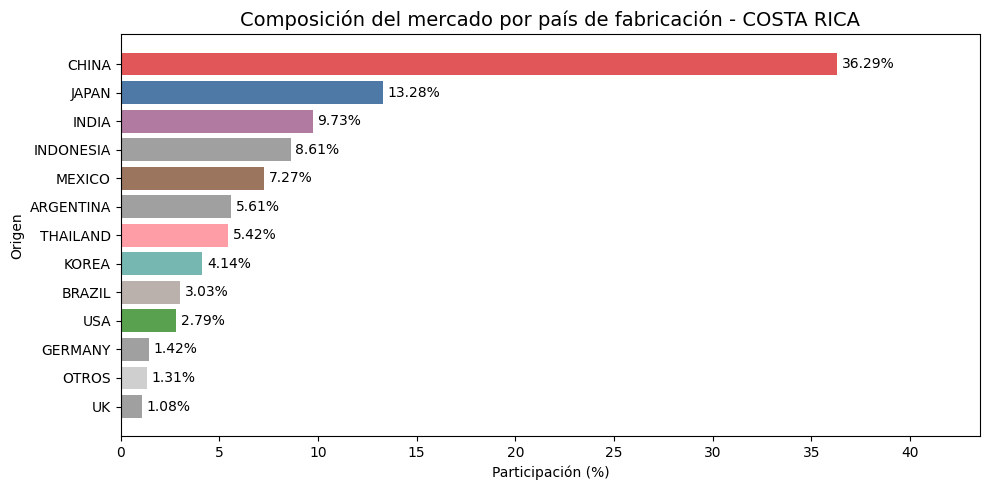

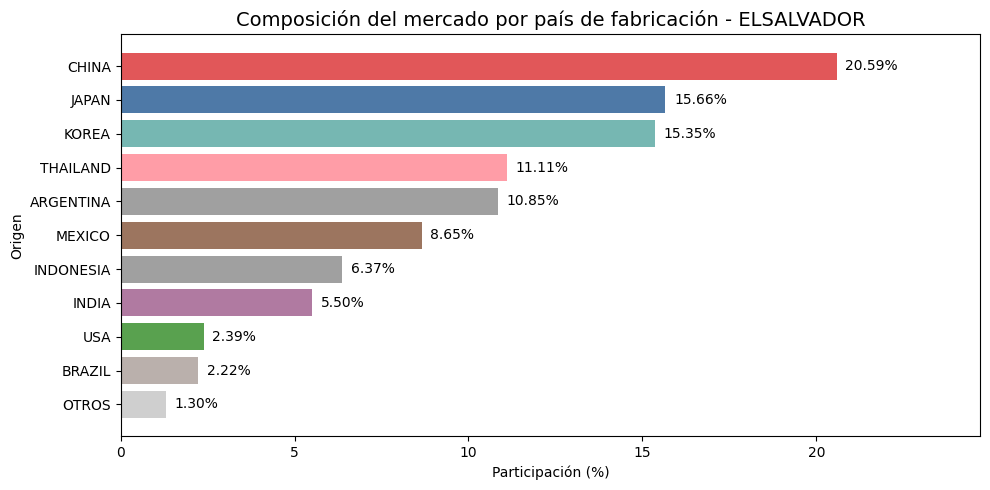

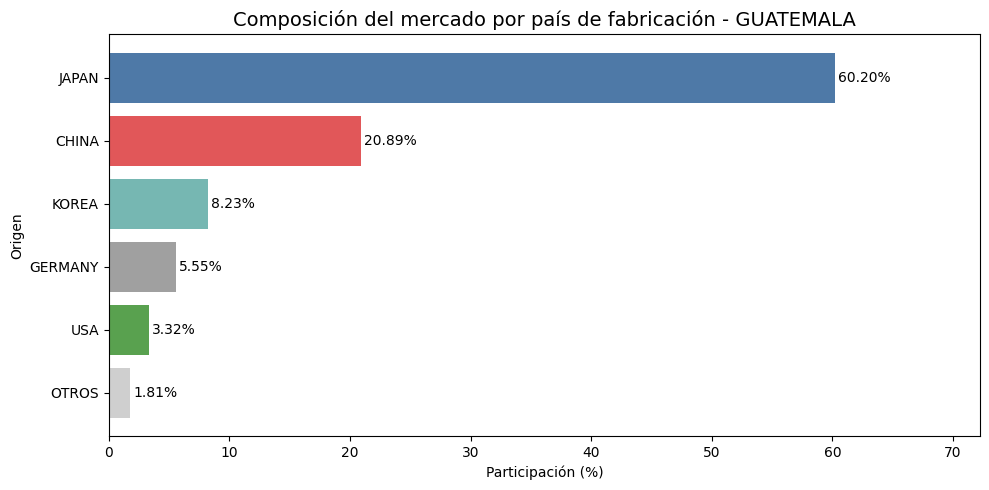

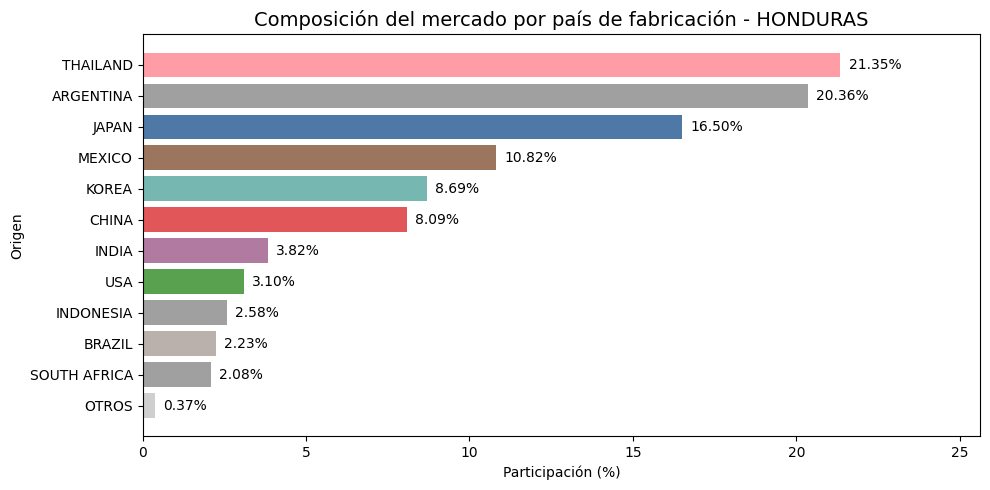

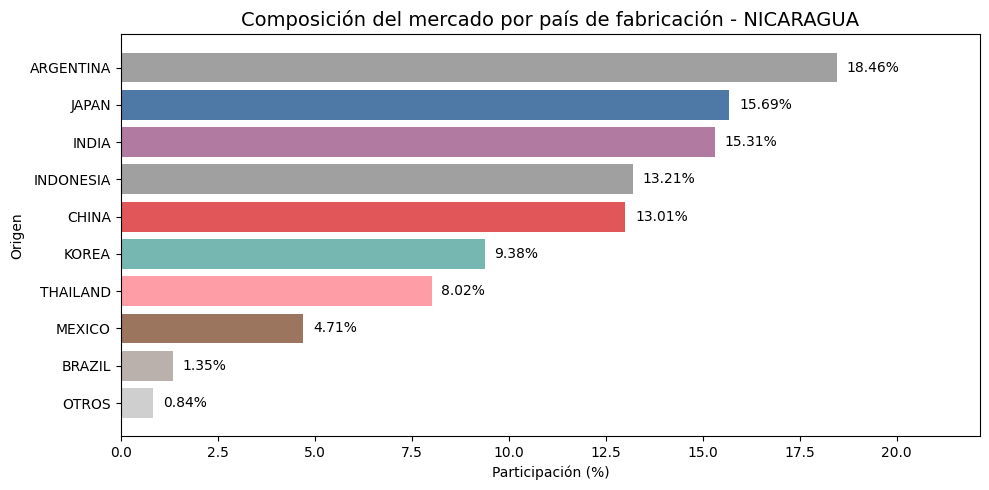

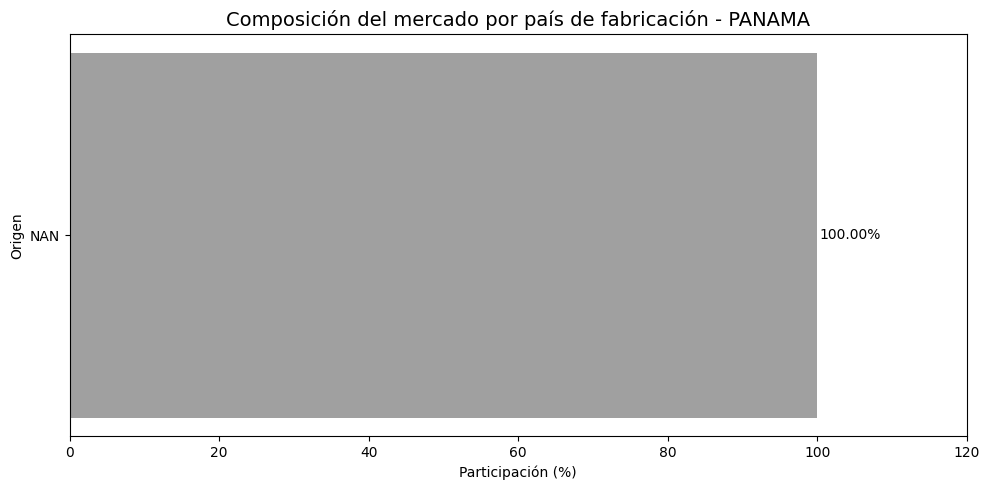

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================
# 1. Preparar dataset
# =====================================

meses = [
    "Jan_25","Feb_25","Mar_25","Apr_25","May_25","Jun_25",
    "Jul_25","Aug_25","Sep_25","Oct_25","Nov_25","Dec_25"
]

meses_existentes = [c for c in meses if c in df_sin_negativos.columns]

df_temp = df_sin_negativos.copy()

# Crear Total_Anual si no existe
if "Total_Anual" not in df_temp.columns:
    df_temp["Total_Anual"] = df_temp[meses_existentes].sum(axis=1)

# Normalizar campos
df_temp["SOURCE"] = df_temp["SOURCE"].astype(str).str.strip().str.upper()
df_temp["Country"] = df_temp["Country"].astype(str).str.strip().str.upper()

# =====================================
# 2. Tabla base de composición
# =====================================

tabla_source = (
    df_temp
    .groupby(["Country", "SOURCE"], as_index=False)["Total_Anual"]
    .sum()
)

tabla_source["Total_Pais"] = tabla_source.groupby("Country")["Total_Anual"].transform("sum")

tabla_source["Share_%"] = (
    tabla_source["Total_Anual"] / tabla_source["Total_Pais"] * 100
).round(2)

# =====================================
# 3. Colores suaves y consistentes
# =====================================

color_map = {
    "JAPAN": "#4E79A7",
    "CHINA": "#E15759",
    "KOREA": "#76B7B2",
    "USA": "#59A14F",
    "EUROPE": "#EDC948",
    "INDIA": "#B07AA1",
    "THAILAND": "#FF9DA7",
    "MEXICO": "#9C755F",
    "BRAZIL": "#BAB0AC",
    "OTROS": "#CFCFCF"
}

# =====================================
# 4. Gráfico por país agrupando <1% en OTROS
# =====================================

paises = sorted(tabla_source["Country"].unique())

for pais in paises:
    
    tabla_pais = tabla_source[tabla_source["Country"] == pais].copy()

    # Separar mayores y menores a 1%
    mayores = tabla_pais[tabla_pais["Share_%"] >= 1].copy()
    menores = tabla_pais[tabla_pais["Share_%"] < 1].copy()

    # Agrupar menores como OTROS
    if len(menores) > 0:
        fila_otros = pd.DataFrame({
            "Country": [pais],
            "SOURCE": ["OTROS"],
            "Total_Anual": [menores["Total_Anual"].sum()],
            "Total_Pais": [tabla_pais["Total_Pais"].iloc[0]],
            "Share_%": [menores["Share_%"].sum()]
        })
        tabla_final = pd.concat([mayores, fila_otros], ignore_index=True)
    else:
        tabla_final = mayores.copy()

    # Ordenar de menor a mayor para barra horizontal
    tabla_final = tabla_final.sort_values("Share_%", ascending=True).reset_index(drop=True)

    # Asignar colores
    colores = [color_map.get(src, "#A0A0A0") for src in tabla_final["SOURCE"]]

    # Crear gráfico
    plt.figure(figsize=(10, 5))
    bars = plt.barh(tabla_final["SOURCE"], tabla_final["Share_%"], color=colores)

    plt.title(f"Composición del mercado por país de fabricación - {pais}", fontsize=14)
    plt.xlabel("Participación (%)")
    plt.ylabel("Origen")

    # Etiquetas de porcentaje
    for i, v in enumerate(tabla_final["Share_%"]):
        plt.text(v + 0.25, i, f"{v:.2f}%", va="center", fontsize=10)

    plt.xlim(0, max(tabla_final["Share_%"]) * 1.2)
    plt.tight_layout()
    plt.show()